In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [4]:
evaluations = pd.read_csv('../evaluations_full_02062025.csv')

Processed 1037 models successfully
Retained 991 data points with ≥2 replicates
Analyzing 10 unique HLAs across 8 regimes

Fitting mixed-effects models...
  ✓ PT H 30L: converged
    Fixed effects: Intercept=-0.425, Slope=0.127
  ✓ PT E 30L: converged
    Fixed effects: Intercept=0.232, Slope=0.049
  ✓ Non-PT H 30L: converged
    Fixed effects: Intercept=0.012, Slope=0.075
  ✓ PT E 0L: converged
    Fixed effects: Intercept=-0.244, Slope=0.073
  ✓ Non-PT H 0L: converged
    Fixed effects: Intercept=0.100, Slope=0.012
  ✓ Non-PT E 30L: converged
    Fixed effects: Intercept=-0.043, Slope=0.081
  ✓ Non-PT E 0L: converged
    Fixed effects: Intercept=-0.137, Slope=0.057
  ✓ PT H 0L: converged
    Fixed effects: Intercept=-0.545, Slope=0.091

Generating model-based predictions with bootstrap CIs...
  Processing PT H 30L...
  Processing PT E 30L...
  Processing Non-PT H 30L...
  Processing PT E 0L...
  Processing Non-PT H 0L...
  Processing Non-PT E 30L...
  Processing Non-PT E 0L...
  Proce

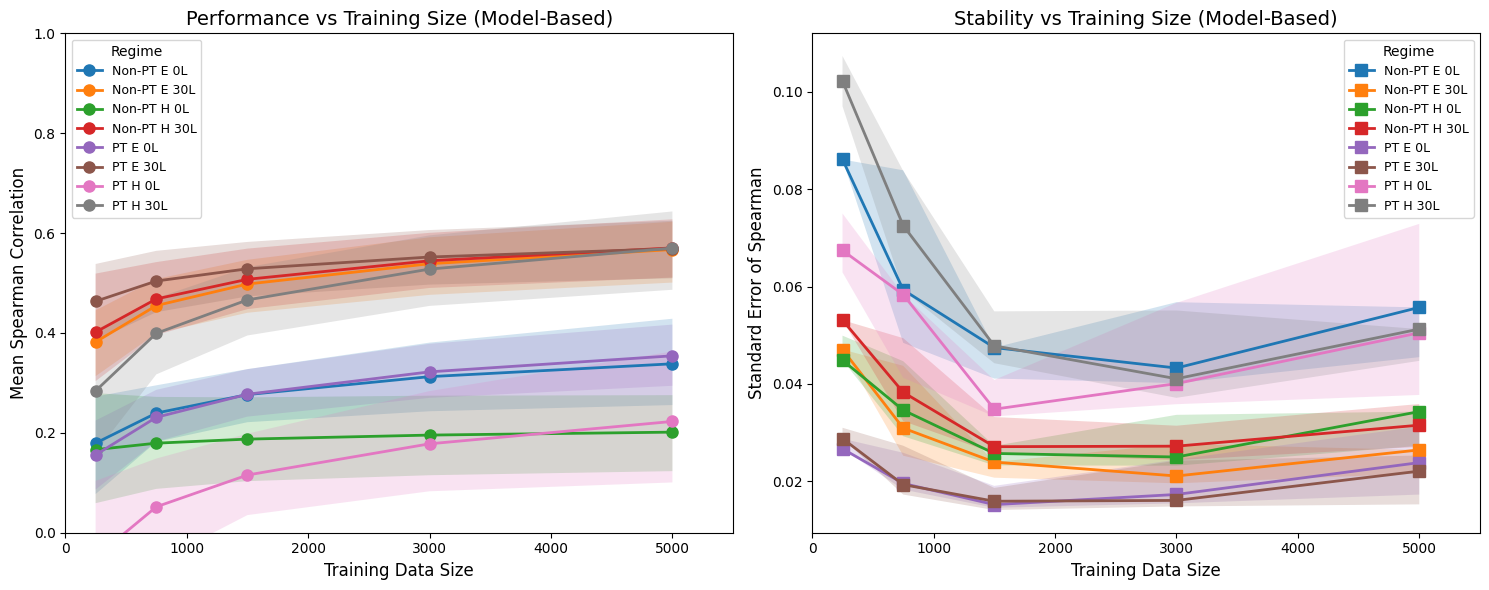


MODEL SUMMARY

PT H 30L:
  Fixed Effects:
    Intercept: -0.4253
    Slope (log_training_data): 0.1271
  Random Effects SD: 0.1834
  Residual SD: 0.1717

PT E 30L:
  Fixed Effects:
    Intercept: 0.2317
    Slope (log_training_data): 0.0492
  Random Effects SD: 0.1597
  Residual SD: 0.0734

Non-PT H 30L:
  Fixed Effects:
    Intercept: 0.0119
    Slope (log_training_data): 0.0753
  Random Effects SD: 0.1705
  Residual SD: 0.1099

PT E 0L:
  Fixed Effects:
    Intercept: -0.2441
    Slope (log_training_data): 0.0726
  Random Effects SD: 0.1154
  Residual SD: 0.0547

Non-PT H 0L:
  Fixed Effects:
    Intercept: 0.1002
    Slope (log_training_data): 0.0119
  Random Effects SD: 0.1765
  Residual SD: 0.0799

Non-PT E 30L:
  Fixed Effects:
    Intercept: -0.0429
    Slope (log_training_data): 0.0805
  Random Effects SD: 0.1539
  Residual SD: 0.0779

Non-PT E 0L:
  Fixed Effects:
    Intercept: -0.1368
    Slope (log_training_data): 0.0573
  Random Effects SD: 0.1264
  Residual SD: 0.1258

P

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error
from scipy import stats
import statsmodels.formula.api as smf
from scipy.stats import bootstrap
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    'min_replicates': 2,
    'min_test_samples': 20,
    'year_cutoff_primary': 2019,
    'year_cutoff_fallback': 1995,
    'plot_points': [250, 750, 1500, 3000, 5000],
    'confidence_level': 0.95,
    'bootstrap_iterations': 500  # Reduced for computational efficiency
}

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def fisher_z_transform(r):
    """Fisher Z transformation for correlation coefficients"""
    r_clipped = np.clip(r, -0.9999, 0.9999)
    return np.arctanh(r_clipped)

def inverse_fisher_z(z):
    """Inverse Fisher Z transformation"""
    return np.tanh(z)

# ============================================================================
# 1. COMPUTE METRICS FOR EACH MODEL (REMOVING TRAINING OVERLAP)
# ============================================================================

results = []
test_datasets_list = []

# Process ALL models/replicates (no selection)
for idx, row in evaluations.iterrows():
    allele = row['Model']
    formatted_HLA = allele.split(' ')[0]
    test_path = row['path']
    
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"
    
    try:
        # Load training data
        epitope_data = pd.read_csv(train_fasta, header=None)
        epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                                'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
        
        epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)
        
        # Apply year cutoff
        if epitope_data[epitope_data["Year_submission"] < CONFIG['year_cutoff_primary']].empty:
            epitope_data = epitope_data[epitope_data["Year_submission"] > CONFIG['year_cutoff_fallback']]
        else:
            epitope_data = epitope_data[epitope_data["Year_submission"] < CONFIG['year_cutoff_primary']]
        
        # Load test data and remove training overlap
        test_dataset = pd.read_csv(test_path)
        test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
        
        if test_dataset.empty or len(test_dataset) <= CONFIG['min_test_samples']:
            continue
        
        # Compute metrics
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        results.append({
            "HLA": formatted_HLA,
            "spearman": spearman_val,
            "pearsonr": pearson_val,
            "mse": mse_val,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data),
            "encoding": row['encoding'],
            "Model": allele,
            "replicate_id": idx  # Track original row
        })
        
        # Store test dataset
        test_dataset = test_dataset.copy()
        test_dataset['HLA'] = allele
        test_datasets_list.append(test_dataset)
            
    except Exception as e:
        print(f"Error processing {allele} (row {idx}): {e}")
        continue

metrics_df = pd.DataFrame(results)
test_datasets_df = pd.concat(test_datasets_list, ignore_index=True) if test_datasets_list else pd.DataFrame()

print(f"Processed {len(metrics_df)} models successfully")

# ============================================================================
# 2. PREPARE DATA WITH CONTINUOUS TRAINING SIZE
# ============================================================================

# Add pretrain indicator
evaluations['pretrain'] = ~evaluations['path'].str.contains('False')
evaluations['pretrain'] = evaluations['pretrain'].replace({True: 'Pretrained', False: 'Not Pretrained'})

# Create unique replicate ID
evaluations['replicate_id'] = (
    evaluations['HLA'].astype(str) + '_' + 
    evaluations['encoding'].astype(str) + '_' + 
    evaluations['trained_blocks'].astype(str) + '_' +
    evaluations['data_prop'].astype(str) + '_' +
    evaluations.groupby(['HLA', 'encoding', 'trained_blocks', 'data_prop']).cumcount().astype(str)
)

# Merge metrics with evaluations
evaluations_dt_plot = pd.merge(
    left=metrics_df[['HLA', 'training_data', 'replicate_id']], 
    right=evaluations, 
    left_on='replicate_id',
    right_index=True,
    how='right'
)

# Calculate actual training data used (CONTINUOUS)
evaluations_dt_plot['training_data'] = (
    evaluations_dt_plot['training_data'].astype(float) * 
    evaluations_dt_plot['data_prop'].astype(float)
)

# Log transform for modeling
evaluations_dt_plot['log_training_data'] = np.log1p(evaluations_dt_plot['training_data'])

# Apply Fisher Z transformation to Spearman correlations
evaluations_dt_plot['spearman'] = evaluations_dt_plot['spearman'].astype(float)
evaluations_dt_plot['z_spearman'] = fisher_z_transform(evaluations_dt_plot['spearman'])

# Create group labels
evaluations_dt_plot['group_label'] = (
    evaluations_dt_plot['pretrain'].map({'Pretrained': 'PT', 'Not Pretrained': 'Non-PT'}) + ' ' +
    evaluations_dt_plot['encoding'].map({'HLA': 'H', 'epitope': 'E'}) + ' ' +
    evaluations_dt_plot['trained_blocks'].map({0: '0L', 30: '30L'})
)


# ============================================================================
# 3. FILTER FOR REPLICATES (≥2 per HLA/group/data_prop combination)
# ============================================================================

# Count unique replicates per (HLA, group_label, data_prop)
replicate_counts = (
    evaluations_dt_plot
    .groupby(['HLA_y', 'group_label', 'data_prop'])['replicate_id']
    .nunique()
    .reset_index(name='n_replicates')
)

# Keep only combinations with sufficient replicates
sufficient_replicates = replicate_counts[
    replicate_counts['n_replicates'] >= CONFIG['min_replicates']
][['HLA_y', 'group_label', 'data_prop']]

# Subset to only those with sufficient replicates
subset = evaluations_dt_plot.merge(
    sufficient_replicates, 
    on=['HLA_y', 'group_label', 'data_prop'],
    how='inner'
)

# Remove rows with missing values
subset = subset.dropna(subset=['z_spearman', 'log_training_data', 'group_label', 'HLA_y'])

print(f"Retained {len(subset)} data points with ≥{CONFIG['min_replicates']} replicates")
print(f"Analyzing {subset['HLA_y'].nunique()} unique HLAs across {subset['group_label'].nunique()} regimes")

# ============================================================================
# 4. FIT MIXED-EFFECTS MODEL (HIERARCHICAL APPROACH)
# ============================================================================

print("\nFitting mixed-effects models...")

regime_models = {}

for regime in subset['group_label'].unique():
    regime_data = subset[subset['group_label'] == regime].copy()
    
    if len(regime_data) < 10:
        print(f"  Skipping {regime}: insufficient data")
        continue
    
    try:
        # Mixed-effects model: z_spearman ~ log_training_data + (1|HLA)
        model = smf.mixedlm(
            "z_spearman ~ log_training_data",
            data=regime_data,
            groups=regime_data["HLA_y"],
            re_formula="~1"
        )
        fitted_model = model.fit(method='powell', maxiter=1000)
        regime_models[regime] = fitted_model
        
        print(f"  ✓ {regime}: converged")
        print(f"    Fixed effects: Intercept={fitted_model.fe_params['Intercept']:.3f}, "
              f"Slope={fitted_model.fe_params['log_training_data']:.3f}")
        
    except Exception as e:
        print(f"  ✗ {regime}: {str(e)[:50]}")
        continue

# ============================================================================
# 5. GENERATE PREDICTIONS USING FITTED MODELS WITH BOOTSTRAP CI
# ============================================================================

def bootstrap_model_predictions(regime_data, fitted_model, plot_points, n_bootstrap=CONFIG['bootstrap_iterations']):
    """
    Bootstrap predictions by resampling HLAs and refitting the model.
    This properly accounts for uncertainty in both fixed and random effects.
    """
    
    results = []
    hlas = regime_data['HLA_y'].unique()
    
    if len(hlas) < 3:
        # Not enough HLAs for meaningful bootstrap
        for train_size in plot_points:
            results.append({
                'train_size': train_size,
                'mean': np.nan,
                'ci_lower': np.nan,
                'ci_upper': np.nan
            })
        return pd.DataFrame(results)
    
    rng = np.random.default_rng(42)
    
    # Store bootstrap predictions for each training size
    bootstrap_preds = {ts: [] for ts in plot_points}
    
    for boot_iter in range(n_bootstrap):
        # Resample HLAs with replacement
        boot_hlas = rng.choice(hlas, size=len(hlas), replace=True)
        
        # Create bootstrap sample (all observations for selected HLAs)
        boot_data = pd.concat([
            regime_data[regime_data['HLA_y'] == hla] 
            for hla in boot_hlas
        ], ignore_index=True)
        
        # Refit model on bootstrap sample
        try:
            boot_model = smf.mixedlm(
                "z_spearman ~ log_training_data",
                data=boot_data,
                groups=boot_data["HLA_y"],
                re_formula="~1"
            )
            boot_fitted = boot_model.fit(method='powell', maxiter=500, disp=False)
            
            # Generate predictions at each plot point (population-level)
            for train_size in plot_points:
                log_train_size = np.log1p(train_size)
                
                # Predict at population level (fixed effects only)
                z_pred = (boot_fitted.fe_params['Intercept'] + 
                         boot_fitted.fe_params['log_training_data'] * log_train_size)
                
                # Transform back to correlation scale
                pred = inverse_fisher_z(z_pred)
                bootstrap_preds[train_size].append(pred)
                
        except Exception as e:
            # If model fails, skip this bootstrap iteration
            continue
    
    # Compute statistics from bootstrap distribution
    for train_size in plot_points:
        preds = bootstrap_preds[train_size]
        
        if len(preds) > 0:
            mean_val = np.mean(preds)
            ci_lower = np.percentile(preds, 2.5)
            ci_upper = np.percentile(preds, 97.5)
        else:
            mean_val = ci_lower = ci_upper = np.nan
        
        results.append({
            'train_size': train_size,
            'mean': mean_val,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'n_bootstrap': len(preds)
        })
    
    return pd.DataFrame(results)


print("\nGenerating model-based predictions with bootstrap CIs...")

curve_stats = []
for regime in regime_models.keys():
    print(f"  Processing {regime}...")
    regime_data = subset[subset['group_label'] == regime]
    fitted_model = regime_models[regime]
    
    regime_pred = bootstrap_model_predictions(regime_data, fitted_model, CONFIG['plot_points'])
    regime_pred['group_label'] = regime
    curve_stats.append(regime_pred)

curve_stats = pd.concat(curve_stats, ignore_index=True)

# ============================================================================
# 6. COMPUTE STABILITY METRICS (WITHIN-HLA VARIANCE)
# ============================================================================

print("\nComputing stability metrics...")

rep_level_stats = []

for regime in regime_models.keys():
    regime_data = subset[subset['group_label'] == regime]
    fitted_model = regime_models[regime]
    
    # Get random effects variance
    re_variance = fitted_model.cov_re.iloc[0, 0]  # Variance of random intercepts
    residual_variance = fitted_model.scale  # Residual variance
    
    for train_size in CONFIG['plot_points']:
        log_train_size = np.log1p(train_size)
        
        # Find observations near this training size
        local_data = regime_data[
            np.abs(regime_data['log_training_data'] - log_train_size) < 0.7
        ]
        
        if len(local_data) < 3:
            continue
        
        # For each HLA, compute SE based on number of replicates
        for hla in local_data['HLA_y'].unique():
            hla_data = local_data[local_data['HLA_y'] == hla]
            n_reps = len(hla_data)
            
            if n_reps >= CONFIG['min_replicates']:
                # SE on Z-scale, then transform
                se_z = np.sqrt(residual_variance / n_reps)
                
                # Get predicted Z value for this HLA/training size
                z_pred = (fitted_model.fe_params['Intercept'] + 
                         fitted_model.fe_params['log_training_data'] * log_train_size)
                
                # Approximate SE in correlation scale using delta method
                # SE(r) ≈ SE(z) * (1 - r²)
                r_pred = inverse_fisher_z(z_pred)
                se_r = se_z * (1 - r_pred**2)
                
                rep_level_stats.append({
                    'group_label': regime,
                    'train_size': train_size,
                    'HLA_y': hla,
                    'se': se_r,
                    'n_replicates': n_reps
                })

rep_level_stats = pd.DataFrame(rep_level_stats)

# Compute median and IQR of SE across HLAs for each regime/training_size
stability_iqr = (
    rep_level_stats
    .groupby(['group_label', 'train_size'])
    .agg(
        median_se=('se', 'median'),
        q25_se=('se', lambda x: x.quantile(0.25)),
        q75_se=('se', lambda x: x.quantile(0.75)),
        n_hlas=('HLA_y', 'nunique')
    )
    .reset_index()
)

print("\n✓ Analysis complete!")
print(f"Final dataset: {len(subset)} data points across {subset['HLA_y'].nunique()} HLAs")
print(f"Successfully fitted {len(regime_models)} regime models")

# ============================================================================
# 7. CREATE PLOTS
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Mean Performance with 95% Bootstrap CI (Model-Based)
for regime, g in curve_stats.groupby('group_label'):
    g = g.dropna(subset=['train_size', 'mean']).sort_values('train_size')
    if g.empty or g['mean'].isna().all():
        continue
    
    ax1.plot(g['train_size'], g['mean'], marker='o', linewidth=2, markersize=8, label=regime)
    ax1.fill_between(g['train_size'], g['ci_lower'], g['ci_upper'], alpha=0.20)

ax1.set_xlabel('Training Data Size', fontsize=12)
ax1.set_ylabel('Mean Spearman Correlation', fontsize=12)
ax1.set_title('Performance vs Training Size (Model-Based)', fontsize=14)
ax1.grid(False)
ax1.legend(title='Regime', fontsize=9, loc='best')
ax1.set_xlim([0, 5500])
ax1.set_ylim([0, 1])

# Plot 2: Stability - Median SE with IQR
for regime, g in stability_iqr.groupby('group_label'):
    g = g.dropna(subset=['train_size']).sort_values('train_size')
    if g.empty:
        continue
    
    ax2.plot(g['train_size'], g['median_se'], marker='s', linewidth=2, markersize=8, label=regime)
    ax2.fill_between(g['train_size'], g['q25_se'], g['q75_se'], alpha=0.20)

ax2.set_xlabel('Training Data Size', fontsize=12)
ax2.set_ylabel('Standard Error of Spearman', fontsize=12)
ax2.set_title('Stability vs Training Size (Model-Based)', fontsize=14)
ax2.grid(False)
ax2.legend(title='Regime', fontsize=9, loc='best')
ax2.set_xlim([0, 5500])

plt.tight_layout()
plt.savefig('../../figures_manuscript/4a_regimes_corrected.pdf', dpi=300, bbox_inches="tight")
plt.show()

# ============================================================================
# 8. SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*80)
print("MODEL SUMMARY")
print("="*80)

for regime, model in regime_models.items():
    print(f"\n{regime}:")
    print(f"  Fixed Effects:")
    print(f"    Intercept: {model.fe_params['Intercept']:.4f}")
    print(f"    Slope (log_training_data): {model.fe_params['log_training_data']:.4f}")
    print(f"  Random Effects SD: {np.sqrt(model.cov_re.iloc[0, 0]):.4f}")
    print(f"  Residual SD: {np.sqrt(model.scale):.4f}")

In [41]:
curve_stats.sort_values(by='train_size')

,train_size,mean,ci_lower,ci_upper,n_bootstrap,group_label
0,250,0.284114,0.160284,0.405758,500,PT H 30L
5,250,0.463434,0.384461,0.538124,500,PT E 30L
15,250,0.155951,0.086564,0.224646,500,PT E 0L
10,250,0.401729,0.303587,0.518855,500,Non-PT H 30L
25,250,0.381998,0.313542,0.445305,500,Non-PT E 30L
30,250,0.179456,0.077373,0.272600,500,Non-PT E 0L
20,250,0.166389,0.059136,0.279555,500,Non-PT H 0L
35,250,-0.048970,-0.236642,0.103776,500,PT H 0L
16,750,0.231128,0.182615,0.286127,500,PT E 0L
21,750,0.179331,0.087795,0.271965,500,Non-PT H 0L


In [38]:
curve_stats.to_csv('../../data/curve_stats.csv',index=False)
stability_iqr.to_csv('../../data/stability_iqr.csv',index=False)